In [31]:
import torch

print(torch.__version__)
import numpy as np
from numpy import pi
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt


2.3.1+cu121


In [2]:
# Check if CUDA is available
if torch.cuda.is_available():
    print("CUDA is available. Number of CUDA devices:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  - Capability: {torch.cuda.get_device_capability(i)}")
        print(f"  - Memory Allocated: {torch.cuda.memory_allocated(i)} bytes")
        print(f"  - Memory Cached: {torch.cuda.memory_reserved(i)} bytes")
else:
    print("CUDA is not available.")

CUDA is available. Number of CUDA devices: 1
Device 0: NVIDIA GeForce RTX 4060 Laptop GPU
  - Capability: (8, 9)
  - Memory Allocated: 0 bytes
  - Memory Cached: 0 bytes


# Section 0: Proofs of concepts with quaternions and integration of rotations. 

In [19]:
r = R.from_quat([0, 0, 1, 2])
r_hat = r.as_euler('zyx', degrees=False)
R.from_euler('zyx', r_hat, degrees=False).as_quat()

array([0.        , 0.        , 0.4472136 , 0.89442719])

In [9]:
def plot_rotated_axes(ax, r, name=None, offset=(0, 0, 0), scale=1):
    colors = ("#FF6666", "#005533", "#1199EE")  # Colorblind-safe RGB
    loc = np.array([offset, offset])
    for i, (axis, c) in enumerate(zip((ax.xaxis, ax.yaxis, ax.zaxis),
                                      colors)):
        axlabel = axis.axis_name
        axis.set_label_text(axlabel)
        axis.label.set_color(c)
        axis.line.set_color(c)
        axis.set_tick_params(colors=c)
        line = np.zeros((2, 3))
        line[1, i] = scale
        line_rot = r.apply(line)
        line_plot = line_rot + loc
        ax.plot(line_plot[:, 0], line_plot[:, 1], line_plot[:, 2], c)
        text_loc = line[1]*1.2
        text_loc_rot = r.apply(text_loc)
        text_plot = text_loc_rot + loc[0]
        ax.text(*text_plot, axlabel.upper(), color=c,
                va="center", ha="center")
    ax.text(*offset, name, color="k", va="center", ha="center",
            bbox={"fc": "w", "alpha": 0.8, "boxstyle": "circle"})

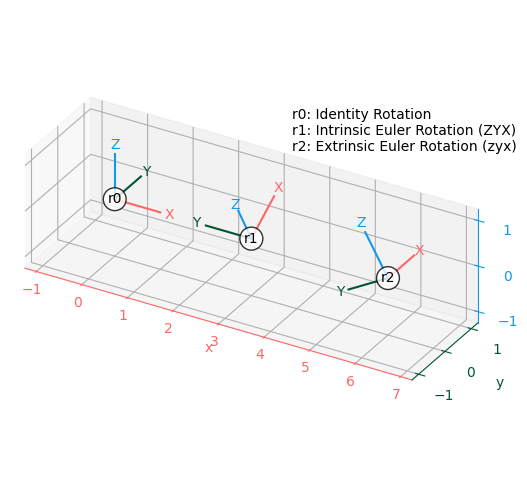

In [12]:
r0 = R.identity()
r1 = R.from_euler("ZYX", [90, -30, 0], degrees=True)  # intrinsic
r2 = R.from_euler("zyx", [90, -30, 0], degrees=True)  # extrinsic

ax = plt.figure().add_subplot(projection="3d", proj_type="ortho")
plot_rotated_axes(ax, r0, name="r0", offset=(0, 0, 0))
plot_rotated_axes(ax, r1, name="r1", offset=(3, 0, 0))
plot_rotated_axes(ax, r2, name="r2", offset=(6, 0, 0))
_ = ax.annotate(
    "r0: Identity Rotation\n"
    "r1: Intrinsic Euler Rotation (ZYX)\n"
    "r2: Extrinsic Euler Rotation (zyx)",
    xy=(0.6, 0.7), xycoords="axes fraction", ha="left"
)
ax.set(xlim=(-1.25, 7.25), ylim=(-1.25, 1.25), zlim=(-1.25, 1.25))
ax.set(xticks=range(-1, 8), yticks=[-1, 0, 1], zticks=[-1, 0, 1])
ax.set_aspect("equal", adjustable="box")
ax.figure.set_size_inches(6, 5)
plt.tight_layout()

In [24]:
r0 = R.from_quat([0, 0, 0, 1])
r1_q = [1, 0, 0, 0]
r2_q = [0, 1, 0, 0]
r1 = R.from_quat(r1_q)
r2 = R.from_quat(r2_q)

print((r0 * r1 * r2).as_quat())
print((r2 * r1 * r0).as_quat())

[0. 0. 1. 0.]
[ 0.  0. -1.  0.]


In [26]:
print(r2.apply(r1.apply(r0.apply([1, 0, 0]))))

[-1.  0.  0.]


In [27]:
print((r2 * r1 * r0).apply([1, 0, 0]))

[-1.  0.  0.]


In [28]:
import Rotations as Rot

In [32]:
angular_displacements = torch.tensor([[0.1, 0.2, 0.3], [0.0, pi, 0.0]])  # Example tensor of angular displacements
rotations = Rot.exp_quat(angular_displacements)

print(rotations)

tensor([[ 9.8255e-01,  4.9709e-02,  9.9418e-02,  1.4913e-01],
        [-4.3711e-08,  0.0000e+00,  1.0000e+00,  0.0000e+00]])
